# 이상지질혈증 예측 - CatBoost Optuna SHAP 분석

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: CatBoost (Optuna 최적 파라미터)
- 데이터: x1_preprocessed.csv
- 분석: OOF 전체 기준 SHAP 피처 기여도 해석
- Threshold: 0.50 고정
- 검증: Stratified 5-Fold CV

In [ ]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
NPY_DIR = "/Users/Jiyeon/Desktop/final_project/ML/outputs/oof"
RANDOM_STATE = 42
THRESHOLD = 0.50

## 1. 데이터 로드 & 피처/타겟 분리

In [2]:
df = pd.read_csv(INPUT_PATH)
TARGET = "이상지질혈증유병"
DROP_COLS = ["이상지질혈증유병", "당뇨유병", "이상지질혈증유병", "비만단계"]
data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  고혈압: {pos}")

샘플 수: 6033  |  정상: 4475  |  고혈압: 1558


## 2. Optuna 최적 파라미터 설정

In [3]:
best_params = dict(
    iterations=612,
    learning_rate=0.037200421858988524,
    depth=4,
    l2_leaf_reg=9.932782455722133,
    bagging_temperature=0.617454472993021,
    random_strength=0.39387167186626176,
    border_count=192,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights={0: 1.0, 1: ratio},
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)
print("파라미터 설정 완료")

파라미터 설정 완료


## 3. Stratified 5-Fold CV — OOF proba & SHAP 수집

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
shap_values = np.zeros(X.shape)
fold_scores = []

print("=" * 55)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**best_params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    explainer = shap.TreeExplainer(model)
    shap_values[val_idx] = explainer.shap_values(X_val)
    pred = (proba >= THRESHOLD).astype(int)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | F1: {fold_scores[-1]['f1']:.4f}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 55)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f} | "
    f"Recall: {scores_df.recall.mean():.4f} | F1: {scores_df.f1.mean():.4f}"
)

  Fold 1 | AUC: 0.8281 | Recall: 0.7532 | F1: 0.5897
  Fold 2 | AUC: 0.8273 | Recall: 0.8141 | F1: 0.6188
  Fold 3 | AUC: 0.8356 | Recall: 0.8141 | F1: 0.6165
  Fold 4 | AUC: 0.8449 | Recall: 0.8039 | F1: 0.6188
  Fold 5 | AUC: 0.8497 | Recall: 0.8360 | F1: 0.6273
  평균   | AUC: 0.8371 | Recall: 0.8043 | F1: 0.6142


## OOF proba 저장 (.npy)

In [5]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_catboost_optuna_shap.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/outputs/oof/oof_proba_HL_catboost_optuna_shap.npy
로드 확인: shape=(6033, 2), 일치=True


---
# SHAP 분석

## 4. SHAP Feature Importance (mean |SHAP|)

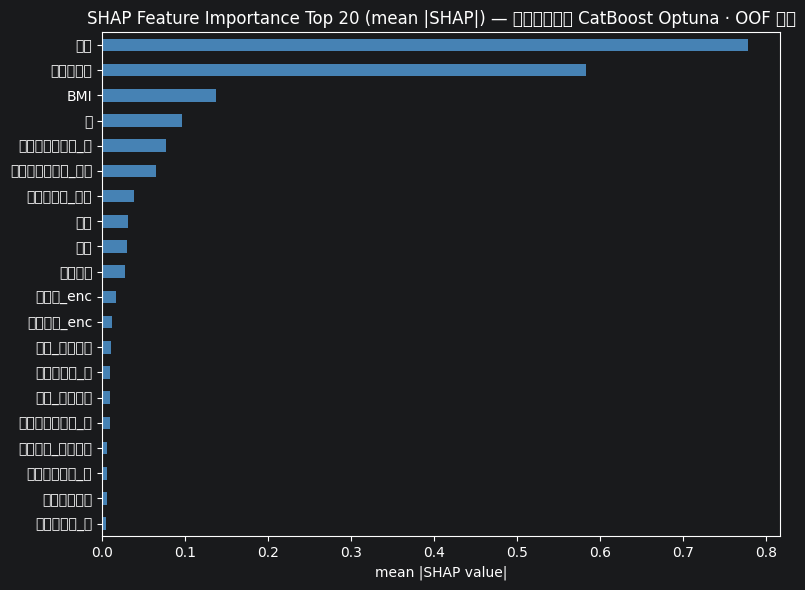

[SHAP Feature Importance Top 15]
   1. 나이: 0.7783
   2. 고혈압유병: 0.5831
   3. BMI: 0.1376
   4. 키: 0.0961
   5. 고지혈증가족력_모: 0.0769
   6. 고지혈증가족력_형제: 0.0654
   7. 당뇨가족력_형제: 0.0383
   8. 체중: 0.0315
   9. 성별: 0.0304
  10. 걷기일수: 0.0273
  11. 음주량_enc: 0.0170
  12. 음주빈도_enc: 0.0120
  13. 직업_관리전문: 0.0111
  14. 당뇨가족력_부: 0.0098
  15. 직업_주부학생: 0.0098


In [6]:
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 이상지질혈증 CatBoost Optuna · OOF 전체")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

print("[SHAP Feature Importance Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 5. SHAP Summary Plot (Beeswarm)

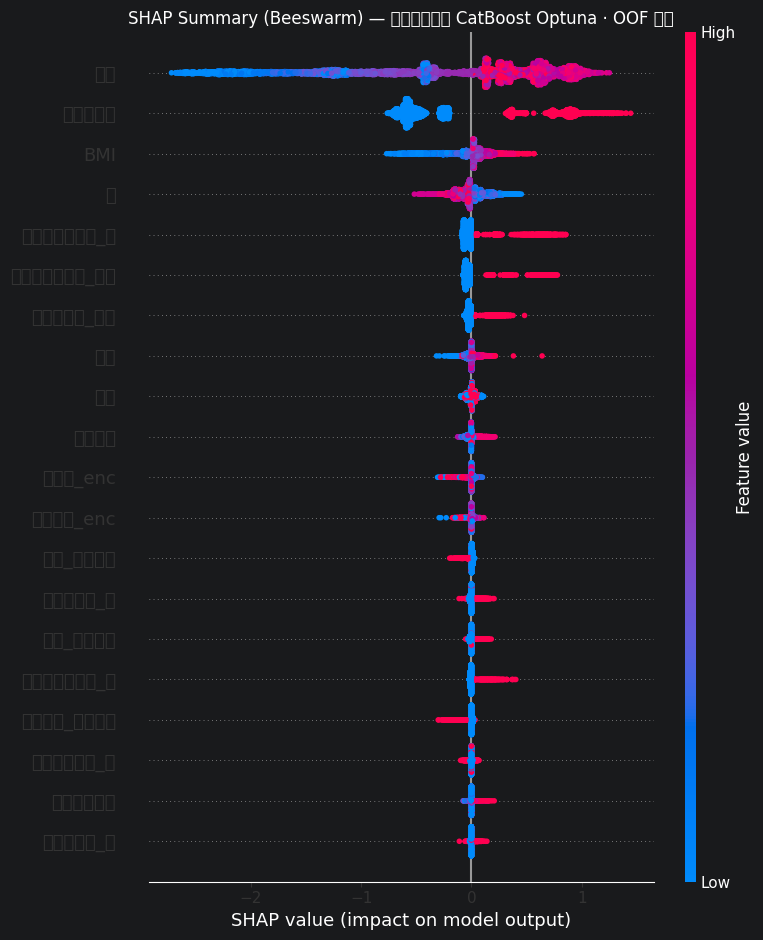

In [7]:
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 이상지질혈증 CatBoost Optuna · OOF 전체", fontsize=12)
plt.tight_layout()
plt.show()

## 6. SHAP Dependence Plot — 나이, BMI

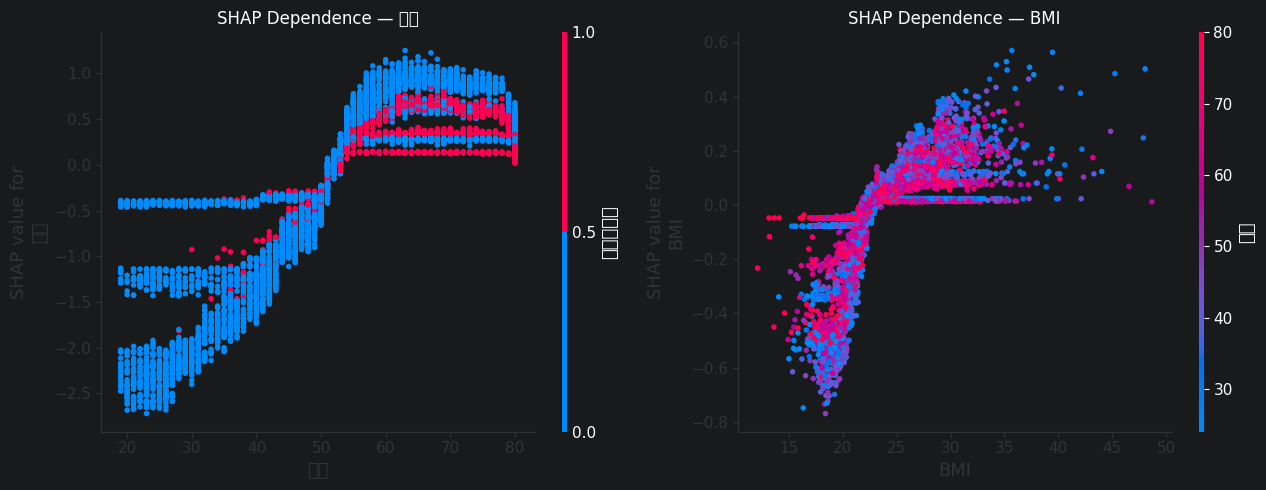

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, ["나이", "BMI"]):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence — {feat}")
plt.tight_layout()
plt.show()

## 7. SHAP Dependence Plot — 고혈압 가족력 3종

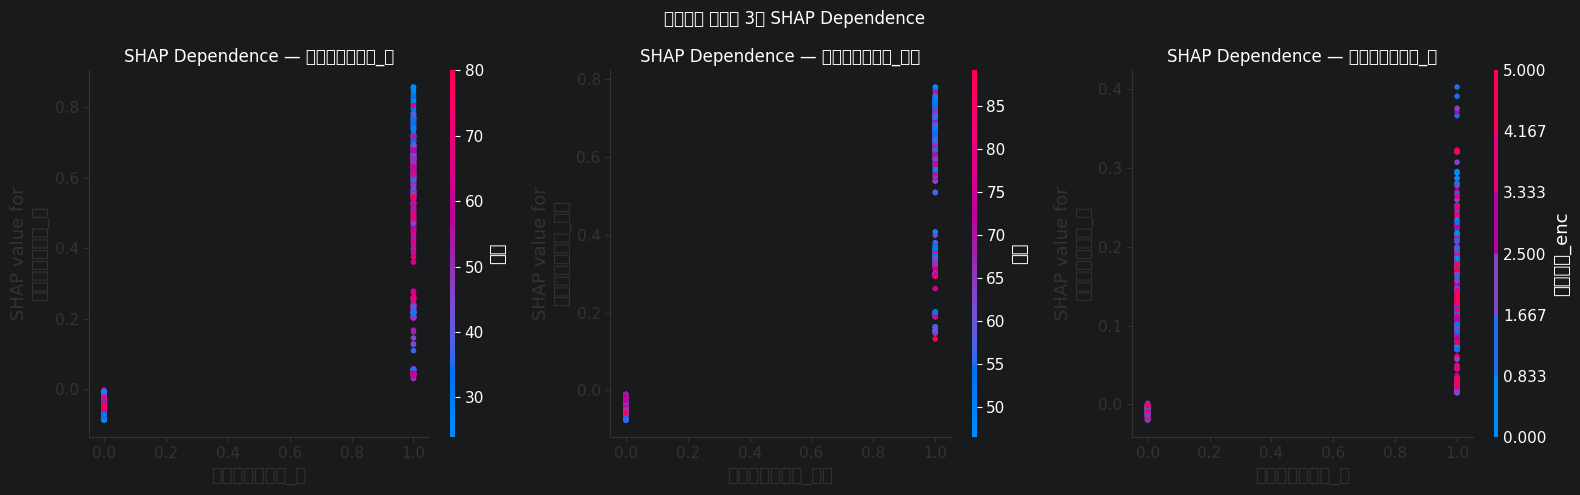

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ["고지혈증가족력_모", "고지혈증가족력_형제", "고지혈증가족력_부"]):
    shap.dependence_plot(feat, shap_values, X, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence — {feat}")
plt.suptitle("고지혈증 가족력 3종 SHAP Dependence", fontsize=12)
plt.tight_layout()
plt.show()

## 8. SHAP Waterfall — 고위험 / 저위험 샘플

[고위험] index=3888 | proba=0.9490 | 실제=1


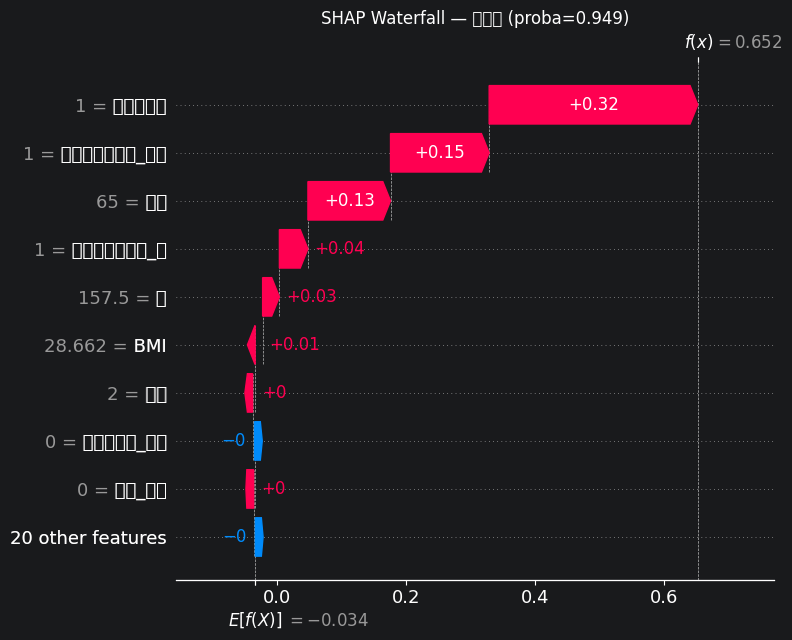

[저위험] index=342 | proba=0.0075 | 실제=0


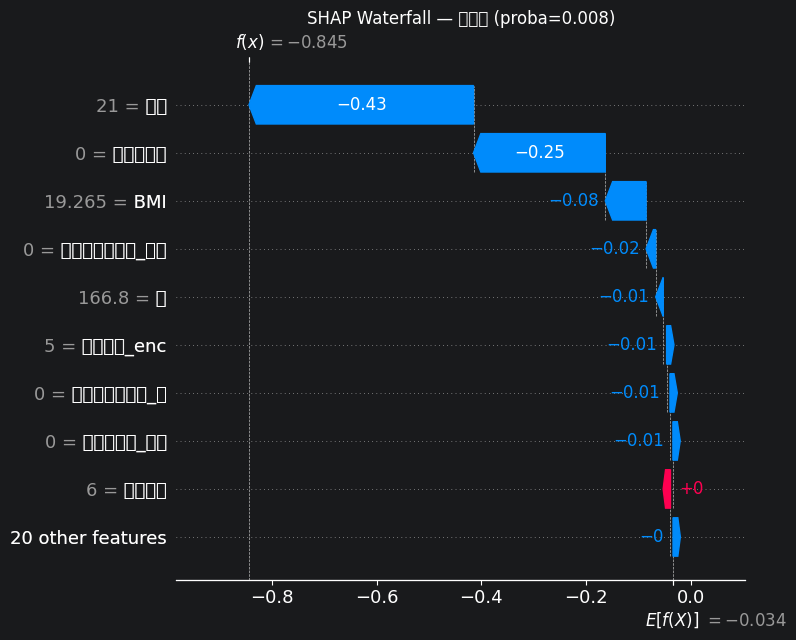

In [10]:
explainer_last = shap.TreeExplainer(model)
for idx, label in [(np.argsort(oof_proba)[::-1][0], "고위험"), (np.argsort(oof_proba)[0], "저위험")]:
    shap_exp = explainer_last(X.iloc[[idx]])
    print(f"[{label}] index={idx} | proba={oof_proba[idx]:.4f} | 실제={y.iloc[idx]}")
    shap.waterfall_plot(shap_exp[0], show=False)
    plt.title(f"SHAP Waterfall — {label} (proba={oof_proba[idx]:.3f})")
    plt.tight_layout()
    plt.show()

## 9. XGBoost vs CatBoost SHAP 비교

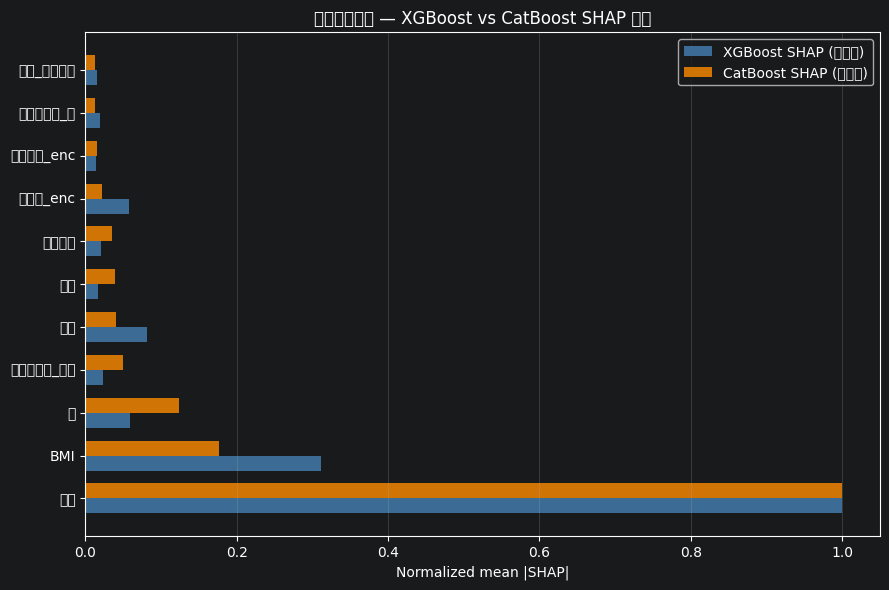

Feature                   XGBoost   CatBoost
---------------------------------------------
나이                         1.5472     0.7783
BMI                        0.4810     0.1376
키                          0.0907     0.0961
당뇨가족력_형제                   0.0360     0.0383
체중                         0.1257     0.0315
성별                         0.0261     0.0304
걷기일수                       0.0312     0.0273
음주량_enc                    0.0893     0.0170
음주빈도_enc                   0.0208     0.0120
당뇨가족력_부                    0.0293     0.0098
직업_주부학생                    0.0244     0.0098


In [11]:
# XGBoost Optuna SHAP Top 15 (이전 분석 결과)
xgb_shap = {
    "나이": 1.5472,
    "BMI": 0.4810,
    "고혈압가족력_모": 0.2660,
    "고혈압가족력_형제": 0.1708,
    "고혈압가족력_부": 0.1566,
    "체중": 0.1257,
    "키": 0.0907,
    "음주량_enc": 0.0893,
    "당뇨가족력_형제": 0.0360,
    "걷기일수": 0.0312,
    "당뇨가족력_부": 0.0293,
    "성별": 0.0261,
    "직업_주부학생": 0.0244,
    "근력운동일수": 0.0214,
    "음주빈도_enc": 0.0208,
}
cat_shap = mean_shap.head(15).to_dict()

common = sorted(set(xgb_shap) & set(cat_shap), key=lambda x: cat_shap.get(x, 0), reverse=True)
max_xgb = max(xgb_shap.values())
max_cat = max(cat_shap.values())

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(common))
w = 0.35
ax.barh(
    x - w / 2, [xgb_shap[f] / max_xgb for f in common], w, label="XGBoost SHAP (정규화)", color="steelblue", alpha=0.8
)
ax.barh(
    x + w / 2, [cat_shap[f] / max_cat for f in common], w, label="CatBoost SHAP (정규화)", color="darkorange", alpha=0.8
)
ax.set_yticks(x)
ax.set_yticklabels(common)
ax.set_xlabel("Normalized mean |SHAP|")
ax.set_title("이상지질혈증 — XGBoost vs CatBoost SHAP 비교")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'Feature':<22} {'XGBoost':>10} {'CatBoost':>10}")
print("-" * 45)
for f in common:
    print(f"{f:<22} {xgb_shap[f]:>10.4f} {cat_shap[f]:>10.4f}")

## 10. DB 로그 저장

In [12]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="CatBoost",
    stage="optuna_shap",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "depth": best_params["depth"],
        "n_estimators": best_params["iterations"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "bagging_temperature": best_params["bagging_temperature"],
        "random_strength": best_params["random_strength"],
        "border_count": best_params["border_count"],
    },
    data_info={"feature_count": X.shape[1], "train_test_split": "5-Fold CV", "scaling_method": "None"},
    oof_metrics={
        "accuracy": float((pred_oof == y).mean()),
        "recall": recall_score(y, pred_oof),
        "precision": precision_score(y, pred_oof),
        "f1_score": f1_score(y, pred_oof),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=mean_shap.head(15).to_dict(),
    note="Optuna 최적 파라미터 기준 SHAP. top_features = SHAP mean|shap| 기준.",
)
print(f"저장 완료 → run_id: {run_id}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=14 | 이상지질혈증 CatBoost (optuna_shap)
저장 완료 → run_id: 14
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     14 2026-05-16 00:35:12     이상지질혈증   CatBoost    optuna_shap 0.825566 0.804236   0.497025  0.614366  0.739267
     13 2026-05-15 23:45:25     이상지질혈증   CatBoost threshold_0.45 0.834261 0.869705   0.456690  0.598895  0.699155
     12 2026-05-15 23:45:24         당뇨   CatBoost threshold_0.45 0.821971 0.842170   0.279346  0.419533  0.686723
     11 2026-05-15 23:45:23        고혈압   CatBoost threshold_0.50 0.858479 0.829762   0.530441  0.647168  0.748052
     10 2026-05-15 19:09:58     이상지질혈증    XGBoost    optuna_shap 0.788701 0.835687   0.427867  0.565964  0.668987
      9 2026-05-15 19:00:15     이상지질혈증    XGBoost         optuna 0.803302 0.879974   0.421328  0.569825  0.656887
      8 2026-05-15 18:06:03     이상지질혈증    XGBoost threshold_0.45 0.787916 0.842747   0.412893  0.554242  0.649925
     